In [15]:
!pip install gymnasium ale-py autorom


In [9]:
!AutoROM --accept-license


AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	C:\Users\zaria\anaconda3\Lib\site-packages\AutoROM\roms

Existing ROMs will be overwritten.


C:\Users\zaria\anaconda3\Lib\site-packages\AutoROM\AutoROM.py:264: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [17]:
!pip install pygame


In [18]:
!pip install opencv-python


In [19]:
%pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [1]:
import gymnasium as gym
import ale_py
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import torch
import torch.nn as nn
import torch.optim as optim


In [2]:
gym.register_envs(ale_py)

# Training env — RAM only, no rendering (rendering during training slows things down a lot)
env = gym.make("ALE/Freeway-v5", obs_type="ram")


In [3]:
# ---------------------------
# RAM MAP (verified against real game data)
# ---------------------------
# byte 14       = chicken Y position
#                  6   = bottom (start)
#                  174 = top (just before crossing)
#                  resets to 6 when crossing completes (env reward=1.0 fires)
# bytes 43-52   = car X position for each of the 10 lanes
#                  byte 43 = lane 0 (bottom), byte 52 = lane 9 (top)
# chicken X     = always 48 (horizontally fixed)
#
# Lane boundaries (from live RAM probing):
#   lane 0: y  6-21   (byte 43)
#   lane 1: y 22-37   (byte 44)
#   lane 2: y 38-53   (byte 45)
#   lane 3: y 54-69   (byte 46)
#   lane 4: y 70-85   (byte 47)
#   lane 5: y 86-101  (byte 48)
#   lane 6: y102-117  (byte 49)
#   lane 7: y118-133  (byte 50)
#   lane 8: y134-149  (byte 51)
#   lane 9: y150+     (byte 52)

CHICKEN_X = 48
DANGER_GAP = 30  # gap (in X units) below which a car is considered dangerous
                 # verified: cars with gap < ~30 reliably block upward movement

def get_lane(chicken_y):
    """Return which of the 10 lanes (0=bottom, 9=top) the chicken is in."""
    return max(0, min(9, (chicken_y - 6) // 16))

def get_car_gap(obs, chicken_y):
    """
    Return the horizontal distance between the chicken and the nearest car
    in the chicken's current lane.
    
    Cars move horizontally across each lane, so we read the X position
    from the correct RAM byte for the lane and compare to chicken_x=48.
    """
    lane = get_lane(chicken_y)
    car_x = int(obs[43 + lane])
    return abs(car_x - CHICKEN_X)

def is_in_danger(obs, chicken_y):
    """True if a car is dangerously close in the current lane."""
    return get_car_gap(obs, chicken_y) < DANGER_GAP


In [4]:
# ---------------------------
# NEURAL NETWORK
# ---------------------------
class MLP(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
    def forward(self, x):
        return self.net(x)

# Add 3 for danger, block_up, and block_down flags
# 1. Define the sizes first
input_size = 128 + 3
output_size = env.action_space.n # This equals 3

# 2. Now create the model using those sizes
model = MLP(input_size, output_size)

# 3. Finally, set up the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0003)


In [5]:
# Freeway specific constants
CHICKEN_X = 48
LANE_X_START_RAM = 43  # Changed from 33 to 43 (verified car X positions)
DANGER_THRESHOLD = 30  # Increased to 30 to match your reward logic gap

def is_in_danger(obs, chicken_y):
    current_lane = max(0, min(9, (chicken_y - 6) // 16))
    car_x = obs[LANE_X_START_RAM + current_lane]
    return 1.0 if abs(int(car_x) - int(CHICKEN_X)) < DANGER_THRESHOLD else 0.0

def is_block_up(obs, chicken_y):
    current_lane = max(0, min(9, (chicken_y - 6) // 16))
    if current_lane >= 9: return 0.0
    lane_above_x = obs[LANE_X_START_RAM + current_lane + 1]
    return 1.0 if abs(int(lane_above_x) - int(CHICKEN_X)) < DANGER_THRESHOLD else 0.0

def is_block_down(obs, chicken_y):
    current_lane = max(0, min(9, (chicken_y - 6) // 16))
    if current_lane <= 0: return 0.0
    lane_below_x = obs[LANE_X_START_RAM + current_lane - 1]
    return 1.0 if abs(int(lane_below_x) - int(CHICKEN_X)) < DANGER_THRESHOLD else 0.0
    
def get_augmented_state(obs, chicken_y):
    # 1. Calculate situational flags
    # Assuming is_in_danger is already written similar to the ones above
    danger = is_in_danger(obs, chicken_y) 
    b_up = is_block_up(obs, chicken_y)
    b_down = is_block_down(obs, chicken_y)
    
    # 2. Normalize RAM (0-1)
    normalized_obs = obs.astype(np.float32) / 255.0
    
    # 3. Create the 3 extra features
    extra_features = np.array([float(danger), float(b_up), float(b_down)], dtype=np.float32)
    
    # 4. Combine into a 131-length vector (128 + 3)
    return np.concatenate([normalized_obs, extra_features])


In [10]:
# ---------------------------
# TRAINING 
# ---------------------------
RESET_TRAINING   = False  # True = start fresh, False = resume from checkpoint

episodes         = 500    # set to 1000-5000 for real training
gamma            = 0.99   # discount factor — makes agent care about future rewards
checkpoint_every = 10  # save every episode
YOUR_UP_ACTION_INDEX = 1
YOUR_DOWN_ACTION_INDEX = 2

episode_rewards = []
start_episode   = 0

collision_history = []   # total collisions per episode
entropy_history = []     # average entropy per episode

# ---------------------------
# CHECKPOINT LOADING
# ---------------------------
if not RESET_TRAINING:
    try:
        checkpoint = torch.load("checkpoint.pth", weights_only=False)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        episode_rewards = checkpoint.get("episode_rewards", [])
        start_episode   = checkpoint["episode"] + 1
        print(f"Resuming from episode {start_episode}")
    except FileNotFoundError:
        print("No checkpoint found, starting fresh.")
else:
    print("RESET_TRAINING = True → Starting from scratch")

# ---------------------------
# TRAINING LOOP
# ---------------------------

# 1. Get the initial observation from the environment
obs, info = env.reset() 

test_state = get_augmented_state(obs, int(obs[14]))
# print(f"Model Input Shape: {test_state.shape}") # Should say (131,)               deubg

for episode in range(start_episode, episodes):
    #stepc = 0                                              # comment out for debugging
    entropy_coef = max(0.01, 0.05 * (0.999 ** episode))  # floor at 0.01 
    obs, _ = env.reset()

    log_probs = []
    rewards   = []
    entropies = []
    done      = False
    episode_collisions = 0
    episode_entropies = []
    step_count = 0
    max_y_this_episode = int(obs[14])
    
    prev_y = int(obs[14])  # initialize to actual starting Y instead of None
    
    while not done:
        #stepc += 1                                                #comment out for debugging acutally ignore this
        step_count += 1
        block_up = False
        block_down = False
        
        chicken_y = int(obs[14])
        current_lane = max(0, min(9, (chicken_y - 6) // 16))

        # 2. CREATE SMART INPUT (The "Brain" sees the cars now)
        # This uses the method we added to create the 131-length vector
        augmented_state = get_augmented_state(obs, chicken_y)
        state_input = torch.tensor(augmented_state, dtype=torch.float32).unsqueeze(0)

        # 3. AGENT DECIDES
        logits = model(state_input)
        probs = torch.softmax(logits, dim=1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action) 
        entropy = dist.entropy()         
        
        # 4. ENVIRONMENT STEP
        prev_y = chicken_y # save to calculate delta after moving
        obs, env_reward, term, trunc, _ = env.step(action.item())
        done = term or trunc
        
        # 5. POST-STEP MATH (For Reward Logic)
        chicken_y = int(obs[14])
        delta = chicken_y - prev_y
        current_lane = max(0, min(9, (chicken_y - 6) // 16))
        
        # Calculate situational flags for the Reward Function
        car_x_current = int(obs[43 + current_lane])
        gap_current = abs(car_x_current - CHICKEN_X)
        danger = gap_current < DANGER_GAP
        
        lane_above_x = int(obs[43 + current_lane + 1]) if current_lane < 9 else None
        block_up = lane_above_x is not None and abs(lane_above_x - CHICKEN_X) < DANGER_GAP
        
        lane_below_x = int(obs[43 + current_lane - 1]) if current_lane > 0 else None
        block_down = lane_below_x is not None and abs(lane_below_x - CHICKEN_X) < DANGER_GAP

        # --------------------------------------------------------------------------------------
        # rewards 
        if env_reward == 1.0:                  # rewards for reaching the end
            speed_bonus = max(0, 500 - step_count) * 0.01
            # Safety bonus — fewer collisions = bigger reward
            # 0 collisions = full +10 bonus
            # 10+ collisions = no bonus
            safety_bonus = max(0, 50 - episode_collisions) * 0.2
            reward = 20.0 + speed_bonus + safety_bonus  # base down to 10        
            
            # Reset for next crossing within same episode
            step_count = 0
            max_y_this_episode = int(obs[14])
            episode_collisions = 0  # reset so each crossing is judged independently

        elif delta > 0:
            if danger:
                reward = -3.0    # moved up but a car is right there — risky
            else:
                reward = 3.0     # moved up cleanly — good

        elif delta == 0:
            if danger:
                reward = 0.5     # waiting because car is present — smart
            else:
                reward = -1.0    # standing still for no reason — nudge it

        elif delta < 0:
            reward = -0.5        # moved backwards
        prev_y = chicken_y

        # Progress bonus — reward pushing to new heights
        if chicken_y > max_y_this_episode:
            progress_bonus = (chicken_y - max_y_this_episode) * 0.1
            reward += progress_bonus
            max_y_this_episode = chicken_y
        
        if danger and action.item() == 1:
            episode_collisions += 1
        episode_entropies.append(entropy.item())
        log_probs.append(log_prob)
        rewards.append(reward)
        entropies.append(entropy)
        
        #if step % 10 == 0: # Print every 10 steps so it doesn't lag           # debug prints 
            #print(f"Step: {stepc} | Lane: {current_lane} | CarX: {car_x_current} | Act: {action.item()} | Rew: {reward:.2f} | Danger: {danger}")
        #if stepc % 50 == 0:
            #print(f"Y: {chicken_y} | Lane: {current_lane} | CarX: {car_x_current} | Gap: {gap_current} | Danger: {danger} | BlockUp: {block_up}")
        # ----------------------------------------------------------------------------------------
        #step += 1                                                            # debug
        #print(f"Step {step} | Reward: {reward}")                          # debug
        #print(f"chicken_y: {chicken_y}, prev_y: {prev_y}")
        # ---------------------------------------------------------------------------------------

    # ---------------------------
    # DISCOUNTED RETURNS
    # ---------------------------
    # G_t = r_t + γ*r_{t+1} + γ²*r_{t+2} + ...
    # This gives credit to early actions (like waiting) that enabled
    # safe crossing steps later in the episode.
    returns = []
    collision_history.append(episode_collisions)
    entropy_history.append(np.mean(episode_entropies))

    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)
    # Normalize: keeps loss scale stable regardless of episode length
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ---------------------------
    # BASELINE
    # ---------------------------
    # Subtract recent average so the agent learns relative improvement,
    # not just whether the raw reward was positive
    baseline = float(np.mean(episode_rewards[-50:])) if len(episode_rewards) >= 50 else 0.0

    # ---------------------------
    # POLICY UPDATE
    # ---------------------------
    loss = torch.tensor(0.0, requires_grad=True)
    for lp, G_t, ent in zip(log_probs, returns, entropies):
        advantage = G_t - baseline
        loss = loss + (-lp * advantage) + (-entropy_coef * ent)

    optimizer.zero_grad()
    loss.backward()
    # print(f"Episode {episode} Loss: {loss.item():.4f} | Returns Mean: {returns.mean():.4f}")  # debug
    
    # Gradient clipping: prevents one bad episode from wrecking the weights
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    total_reward = sum(rewards)
    episode_rewards.append(total_reward)

    if episode % checkpoint_every == 0:
                                      # Save after every episode
        print(f"Episode {episode:>5} | Reward: {total_reward:>8.2f}")
        torch.save({
            "episode": episode,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "episode_rewards": episode_rewards,
            "collision_history": collision_history,   
            "entropy_history":   entropy_history,     
        }, "checkpoint.pth")
        print(f"  → Checkpoint saved at episode {episode}")

torch.save(model.state_dict(), "freeway_mlp.pth")
print("\nTraining complete. Model saved to freeway_mlp.pth")
env.close()


Resuming from episode 61
Episode    70 | Reward:  1460.66
  → Checkpoint saved at episode 70
Episode    80 | Reward:  1408.40
  → Checkpoint saved at episode 80
Episode    90 | Reward:  1464.79
  → Checkpoint saved at episode 90
Episode   100 | Reward:  1504.19
  → Checkpoint saved at episode 100
Episode   110 | Reward:  1320.89
  → Checkpoint saved at episode 110
Episode   120 | Reward:  1785.48
  → Checkpoint saved at episode 120
Episode   130 | Reward:  1439.28
  → Checkpoint saved at episode 130
Episode   140 | Reward:  1241.85
  → Checkpoint saved at episode 140
Episode   150 | Reward:   988.35
  → Checkpoint saved at episode 150
Episode   160 | Reward:  1217.97
  → Checkpoint saved at episode 160
Episode   170 | Reward:   674.84
  → Checkpoint saved at episode 170
Episode   180 | Reward:   705.34
  → Checkpoint saved at episode 180
Episode   190 | Reward:   707.23
  → Checkpoint saved at episode 190
Episode   200 | Reward:   612.33
  → Checkpoint saved at episode 200
Episode   21

KeyboardInterrupt: 

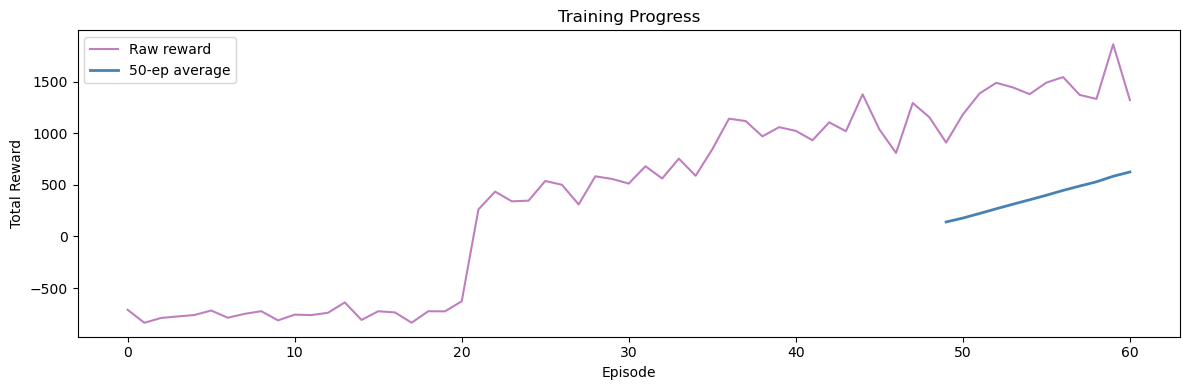

In [7]:
# ---------------------------
# TRAINING PROGRESS PLOT
# ---------------------------
# Raw reward per episode + 50-ep smoothed average.
# Look for:
#   - Upward trend = agent improving
#   - Plateau early = increase entropy_coef to keep exploring
#   - Reward spikes = crossing bonuses kicking in (good!)
# Assuming episode_rewards is your list of rewards per episode

# Load your checkpoint
checkpoint = torch.load("checkpoint.pth", weights_only=False)

# Extract the episode_rewards list
episode_rewards = checkpoint["episode_rewards"]

# Set your smoothing window
window = 50

# Plotting with your actual data
if len(episode_rewards) >= 2:
    current_window = min(window, len(episode_rewards))
    if len(episode_rewards) >= current_window:
        smoothed = np.convolve(episode_rewards, np.ones(current_window)/current_window, mode='valid')
        x_vals = list(range(current_window - 1, len(episode_rewards)))
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(episode_rewards, alpha=0.5, color='purple', linewidth=1.5, label='Raw reward')
        ax.plot(x_vals, smoothed, color='steelblue', linewidth=2, label=f'{current_window}-ep average')
    else:
        # Not enough data for smoothing; just plot raw rewards
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(episode_rewards, alpha=0.25, color='steelblue', label='Raw reward')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title('Training Progress')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Run more episodes to see a meaningful plot.")

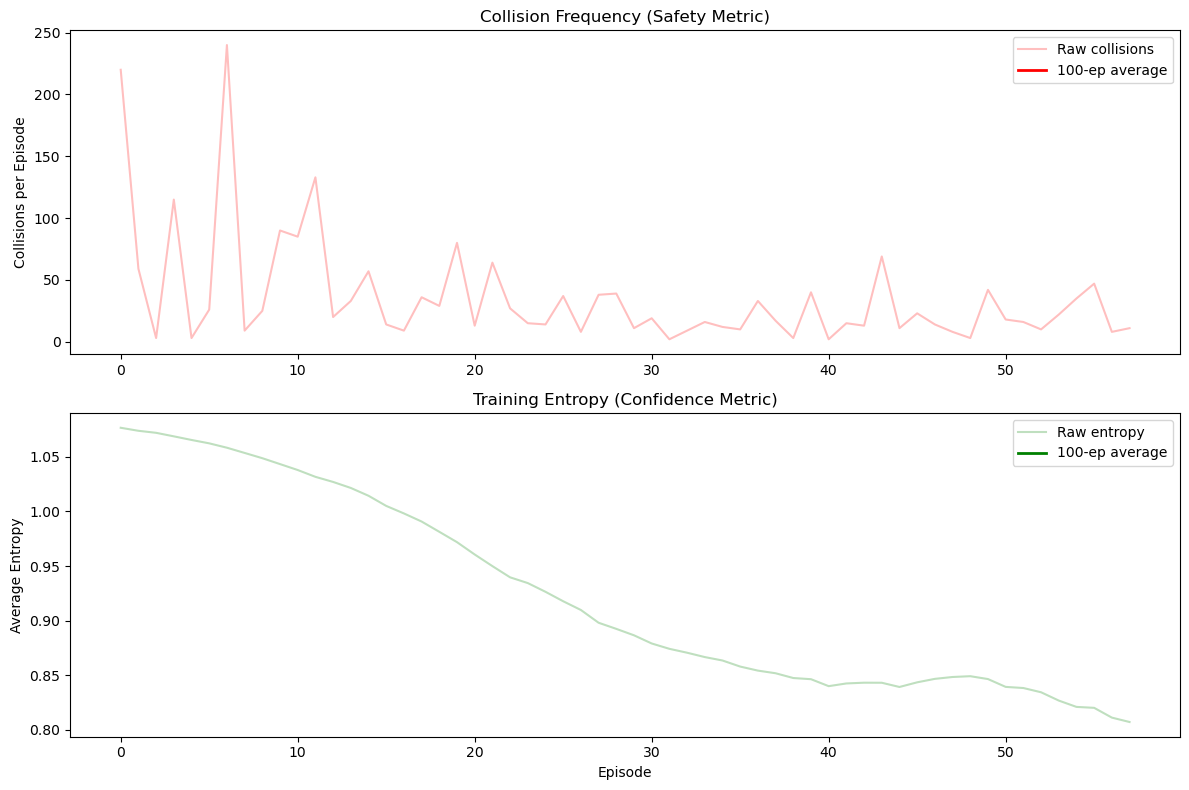

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

window = min(100, len(collision_history))

# Collision frequency
smoothed_col = np.convolve(collision_history, np.ones(window)/window, mode='valid')
ax1.plot(collision_history, alpha=0.25, color='red', label='Raw collisions')
ax1.plot(range(window-1, len(collision_history)), smoothed_col, color='red', linewidth=2, label='100-ep average')
ax1.set_ylabel('Collisions per Episode')
ax1.set_title('Collision Frequency (Safety Metric)')
ax1.legend()

# Entropy
smoothed_ent = np.convolve(entropy_history, np.ones(window)/window, mode='valid')
ax2.plot(entropy_history, alpha=0.25, color='green', label='Raw entropy')
ax2.plot(range(window-1, len(entropy_history)), smoothed_ent, color='green', linewidth=2, label='100-ep average')
ax2.set_ylabel('Average Entropy')
ax2.set_xlabel('Episode')
ax2.set_title('Training Entropy (Confidence Metric)')
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
# ---------------------------
# CONFIDENCE INTERVAL EVALUATION
# ---------------------------
# 1. LOAD THE FINAL MODEL
model.load_state_dict(torch.load("freeway_mlp.pth", weights_only=False))
model.eval()
print("Final model loaded for evaluation.")

# 2. RUN EVALUATION (30-100 episodes)
# We use the evaluation function we fixed earlier
# This gives us fresh data based ONLY on the saved weights
eval_rewards, eval_crossings, eval_collisions = evaluate_model(model, num_episodes=30)

# 3. CALCULATE STATISTICAL EVIDENCE
import scipy.stats as stats

def get_final_metrics(data, name):
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    # 95% Confidence Interval math
    margin = std_err * stats.t.ppf((1 + 0.95) / 2, n - 1)
    print(f"{name}: {mean:.2f} ± {margin:.2f} (Range: [{mean-margin:.2f}, {mean+margin:.2f}])")

print("\n=== FINAL MODEL PERFORMANCE (95% CI) ===")
get_final_metrics(eval_crossings, "Avg Crossings")
get_final_metrics(eval_collisions, "Avg Collisions")

FileNotFoundError: [Errno 2] No such file or directory: 'freeway_mlp.pth'

In [ ]:
# ---------------------------
# PLAY LOOP
# ---------------------------
env_vis = gym.make("ALE/Freeway-v5", render_mode="human")
env_ram = gym.make("ALE/Freeway-v5", obs_type="ram")

# 1. Initial Reset
obs_vis, _ = env_vis.reset(seed=42)
obs_ram, _ = env_ram.reset(seed=42)

# 2. Load the trained model
checkpoint = torch.load("checkpoint.pth", weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print("AI is starting... Press 'q' in the window to stop.")
step_count = 0

while True:
    step_count += 1
    
    # 1. Get the 131 features
    # We pass the full RAM (obs_ram) and just the Chicken Y (obs_ram[14])
    augmented_obs = get_augmented_state(obs_ram, int(obs_ram[14]))
    
    # Define these clearly for the debug print
    d_flag = augmented_obs[-3]  # Danger
    u_flag = augmented_obs[-2]  # Block Up
    
    # 2. Convert to tensor
    ram_input = torch.tensor(augmented_obs, dtype=torch.float32).unsqueeze(0)

    # 3. Model decides the action
    with torch.no_grad():
        logits = model(ram_input)
        action = torch.argmax(logits, dim=1).item()
        
    # 4. DEBUG PRINT - This will tell us exactly what's happening
    #if step_count % 30 == 0: 
        #print(f"Step: {step_count} | Action: {action} | Danger: {d_flag} | Y-Pos: {obs_ram[14]}")
        # print(f"Raw Model Confidence: {logits.numpy()}") # Uncomment if you want to see raw numbers

    # 5. Step BOTH environments
    obs_vis, _, term1, trunc1, _ = env_vis.step(action)
    obs_ram, _, term2, trunc2, _ = env_ram.step(action)

    # 6. Render
    frame_bgr = cv2.cvtColor(obs_vis.copy(), cv2.COLOR_RGB2BGR)
    cv2.imshow("Freeway AI", frame_bgr)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    
    if term1 or trunc1 or term2 or trunc2:
        obs_vis, _ = env_vis.reset(seed=42)
        obs_ram, _ = env_ram.reset(seed=42)

env_vis.close()
env_ram.close()
cv2.destroyAllWindows()


AI is starting... Press 'q' in the window to stop.
